Multiple linear regression in Python

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
data = {
    "Study_Hours" : [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance"  : [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score" : [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}

df = pd.DataFrame(data)

In [3]:
x = df[["Study_Hours","Attendance","Assignment_Score"]]
y = df["Final_Marks"]

In [4]:
model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

print("Intercept : ", model.intercept_)

Intercept :  -28.31652806652808


In [5]:
coefficient_table = pd.DataFrame({
    "Feature" : x.columns,
    "Coefficient" : model.coef_
})

In [6]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.131410
1        Attendance     0.657051
2  Assignment_Score     0.608108


In [7]:
new_student = pd.DataFrame({
    "Study_Hours" : [6],
    "Attendance" : [82],
    "Assignment_Score" : [72]
})

In [8]:
prediction = model.predict(new_student)

print("Predicted final mark : ", prediction[0])

Predicted final mark :  70.13392238392238


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [10]:
model_test = LinearRegression()
model_test.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_test_pred = model_test.predict(x_test)

In [12]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  -28.31652806652808
Slope :  0.13141025641025642
Actual values :  [48 73]
Predicted values :  [41.77477477 48.23198198 53.47297297 61.1463964  67.6036036  73.4527027
 80.51801802 88.79954955]


In [13]:
print("MAE       : ", mean_absolute_error(y_test, y_test_pred))
print("MSE       : ", mean_squared_error(y_test, y_test_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R-squared : ", r2_score(y_test, y_test_pred))

MAE       :  0.4866666666666717
MSE       :  0.27955555555556205
RMSE      :  0.5287301349039621
R-squared :  0.9982108444444444


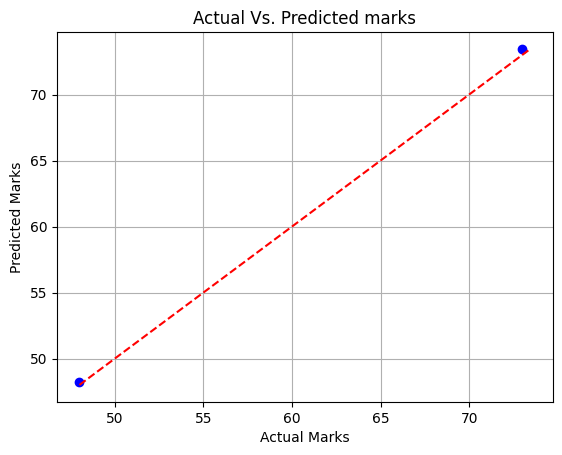

In [14]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

plt.scatter(y_test, y_test_pred, color = "blue")

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()


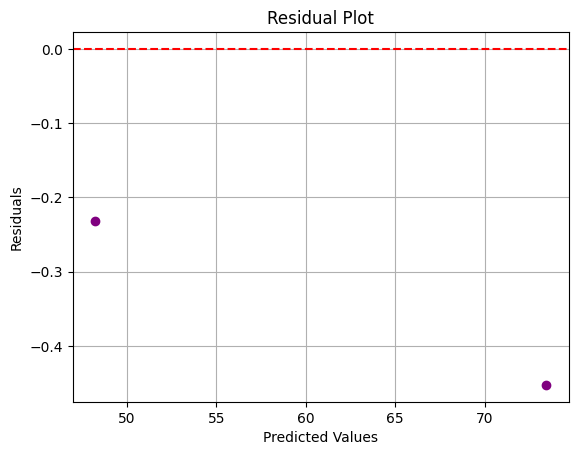

In [15]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


K-FOLD

In [ ]:
np.random.seed(42)
expanded_indices = np.random.choice(df.index, size=100, replace=True)

x = df.loc[expanded_indices, ["Study_Hours", "Attendance", "Assignment_Score"]].values

x = x + np.random.normal(0, 0.1, x.shape)

y = df.loc[expanded_indices, "Final_Marks"].values
y = y + np.random.normal(0, 0.4, y.shape)


In [17]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score

k_values = [4, 5, 6]
test_sizes = [0.20, 0.25, 0.30]
results = []

for k in k_values:
    for test_size in test_sizes:
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)
        
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_scores = []
        
        for train_idx, val_idx in kf.split(x_train):
            x_fold_train, x_fold_val = x_train[train_idx], x_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            
            fold_model = LinearRegression()
            fold_model.fit(x_fold_train, y_fold_train)
            
            y_fold_pred = fold_model.predict(x_fold_val)
            r2 = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(r2)
            
        results.append({
            "K (Folds)": k,
            "Test Size (%)": int(test_size * 100),
            "Fold Scores (R²)": [round(score, 4) for score in fold_scores],
            "Average R²": round(np.mean(fold_scores), 4)
        })


In [18]:
df_results = pd.DataFrame(results)
print("===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====")
df_results


===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====


,K (Folds),Test Size (%),Fold Scores (R²),Average R²
0,4,20,"[0.9971, 0.9985, 0.9988, 0.9984]",0.9982
1,4,25,"[0.9981, 0.9972, 0.9986, 0.9981]",0.9980
2,4,30,"[0.9984, 0.9978, 0.9987, 0.9971]",0.9980
3,5,20,"[0.9967, 0.998, 0.9986, 0.9986, 0.9988]",0.9981
4,5,25,"[0.9984, 0.996, 0.9985, 0.9992, 0.9975]",0.9979
5,5,30,"[0.998, 0.9981, 0.9988, 0.9983, 0.9972]",0.9981
6,6,20,"[0.9944, 0.9985, 0.999, 0.9985, 0.9988, 0.9987]",0.9980
7,6,25,"[0.9985, 0.9969, 0.996, 0.9985, 0.9987, 0.998]",0.9978
8,6,30,"[0.9977, 0.9989, 0.9981, 0.9993, 0.9972, 0.9972]",0.9981


In [21]:
final_model = LinearRegression()
final_model.fit(x_train, y_train)
y_pred = final_model.predict(x_test)

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.4412179769766664
MSE       :  0.27981689916739566
RMSE      :  0.528977219894577
R-squared :  0.9985248289525112


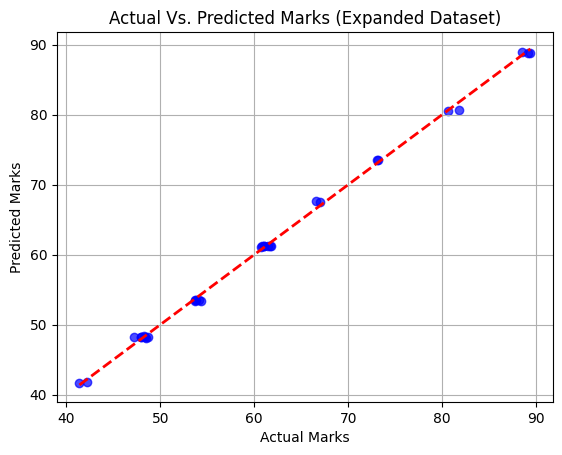

In [22]:
plt.scatter(y_test, y_pred, color="blue", alpha=0.7)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], color="red", linestyle="--", linewidth=2)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted Marks (Expanded Dataset)")
plt.grid(True)
plt.show()


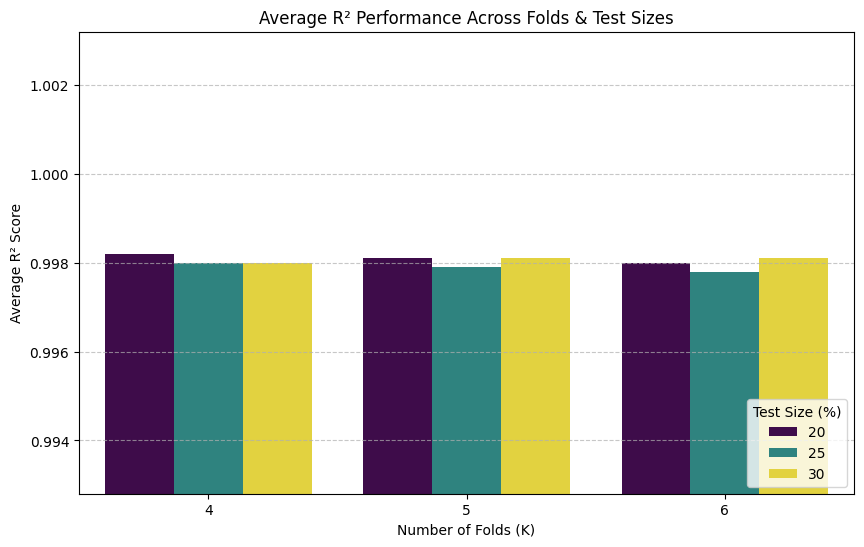

In [20]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="K (Folds)", y="Average R²", hue="Test Size (%)", palette="viridis")

plt.title("Average R² Performance Across Folds & Test Sizes")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Average R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_score = df_results["Average R²"].min()
max_score = df_results["Average R²"].max()
plt.ylim(min_score - 0.005, max_score + 0.005)

plt.legend(title="Test Size (%)", loc="lower right")
plt.show()
